In [11]:
# ============================================================
# Cell 0 — Parameters
# ============================================================
"""
Parameters from Table I of:
Gioannini & Rossetti, "Time-Domain Traveling Wave Model of Quantum Dot DFB Lasers"
IEEE J. Sel. Top. Quantum Electron., Vol. 17, No. 5, 2011

All values are in SI units unless noted.
"""

import numpy as np

# ── Physical constants ────────────────────────────────────────────────────────
q        = 1.602176634e-19   # elementary charge (C)
hbar     = 1.054571817e-34   # reduced Planck constant (J·s)
kB       = 1.380649e-23      # Boltzmann constant (J/K)
c0       = 2.997924580e8     # speed of light in vacuum (m/s)
eps0     = 8.854187817e-12   # vacuum permittivity (F/m)
m0       = 9.1093837015e-31  # free electron mass (kg)
T        = 300.0             # room temperature (K)

# ── Material parameters ───────────────────────────────────────────────────────
h_w      = 5e-9              # QD layer height (m)
eta      = 3.3445            # effective refractive index (dimensionless)
N_l      = 8                 # number of QD layers
N_D      = 5.9e14            # QD surface density (m⁻²)  [5.9×10¹⁰ cm⁻² → ×10⁴]
N_groups = 51                # number of QD groups for inhomogeneous broadening

# State degeneracies: D_m for m = ES2, ES1, GS
D = {
    'ES2': 6,
    'ES1': 4,
    'GS':  2,
}

hbar_Gamma = 7e-3 * q       # homogeneous linewidth (J)  [7 meV → ×q]
Gamma      = hbar_Gamma / hbar  # dephasing rate (rad/s)

Delta_E    = 38e-3 * q      # FWHM of inhomogeneous broadening (J)  [38 meV]

# Dipole matrix elements A_m  (cm³·eV → m³·J)
# 1 cm³·eV = 1e-6 m³ × 1.602e-19 J  →  multiply by 1e-6 * q
A = {
    'ES1': 1.26e-20 * 1e-6 * q,   # m³·J
    'GS':  2.03e-20 * 1e-6 * q,   # m³·J
}

# SCH diffusion/transport times (s)
tau_c_e_W  = 1.2e-12        # electron transport time across SCH (s)
tau_c_h_W  = 23.2e-12       # hole transport time across SCH (s)

tau_e_e_W  = 0.0492e-12

# Electron relaxation times τ_c^{e,m} for m = ES2, ES1, GS (s)
tau_c_e = {
    'ES2': 3e-12,
    'ES1': 2e-12,
    'GS':  2e-12,
}

tau_e_e_im = {
    'ES2': 6.15e-12,
    'ES1': 7.99e-12,
    'GS':  10.63e-12,
}

# Interband recombination time in the WL (s)
tau_r_e_W  = 100e-12

tau_e_h_qd = 1.46E-12

# Spontaneous emission recombination times τ_Sp^m for m = ES2, ES1, GS (s)
tau_Sp = {
    'ES2': 2.8e-9,
    'ES1': 2.8e-9,
    'GS':  2.8e-9,
}

# Auger recombination times τ_Au^m for m = ES2, ES1, GS (s)
tau_Au = {
    'ES2': 110e-12,
    'ES1': 275e-12,
    'GS':  660e-12,
}

# Interband transition energies hbar*omega_im for i=(N+1)/2 (central group)
# m = ES2, ES1, GS  (eV → J)
hbar_omega = {
    'ES2': 1.098 * q,   # J
    'ES1': 1.042 * q,
    'GS':  0.959 * q,   # J
}

# Reference (Bragg) angular frequency — set to GS transition of central group
omega_0 = hbar_omega['GS'] / hbar   # rad/s

# Intrinsic waveguide losses (m⁻¹)  [1.5 cm⁻¹ → ×100]
alpha_i  = 1.5e2

# ── Device parameters ─────────────────────────────────────────────────────────
W        = 2.2e-6            # ridge equivalent width (m)
h_SCH    = 430e-9            # SCH height (m)
r0_sq    = 0.90              # power reflectivity at z=0  (HR facet)
rL_sq    = 0.00              # power reflectivity at z=L  (AR facet)
L        = 400e-6            # total cavity length (m)
k_DFB    = 40e2              # grating coupling coefficient (m⁻¹)  [40 cm⁻¹]

# ── Derived / assumed parameters ──────────────────────────────────────────────
# Internal quantum efficiency (50% per [7] in the paper)
eta_i    = 0.50

# Field confinement factor in QD layers (lateral × transverse)
# Not given in table; typical value for this ridge geometry
Gamma_xy = 0.03             # (dimensionless) — approximate; tune to match gain

# Optical confinement factor of the SCH
Gamma_xy_SCH = 0.3          # (dimensionless) — approximate

# ── QD group energies (Gaussian inhomogeneous distribution) ──────────────────
# Groups indexed i = 0 ... N_groups-1; central group i_c = (N_groups-1)//2
sigma    = Delta_E / (2 * np.sqrt(2 * np.log(2)))   # Gaussian sigma (J)
i_c      = (N_groups - 1) // 2                       # index of central group
i_arr    = np.arange(N_groups)                        # 0 … 50

# Energy offset of each group from central group (evenly spaced, ±3σ span)
# Total span set to 4×FWHM to capture >99% of distribution
E_span   = 4 * Delta_E                               # total span (J)
dE       = E_span / (N_groups - 1)                   # spacing between groups

# GS transition energy for each group
E_GS_i   = hbar_omega['GS'] + (i_arr - i_c) * dE    # (J), shape (N_groups,)

# ES1 and ES2 energies follow same offset as GS (rigid shift of whole spectrum)
E_ES1_i  = hbar_omega['ES1'] + (i_arr - i_c) * dE
E_ES2_i  = hbar_omega['ES2'] + (i_arr - i_c) * dE

# Gaussian weighting G_i (normalised so sum = 1)
G_i      = np.exp(-0.5 * ((i_arr - i_c) * dE / sigma) ** 2)
G_i     /= G_i.sum()

# ── Valence-band confined-state energies (hole states) ───────────────────────
# Five hole confined states (GS, ES1…ES4) equally separated by 12 meV
# (stated in Section III-A of the paper)
delta_h  = 12e-3 * q        # hole level separation (J)
# Hole state energies relative to WL (negative = below WL continuum)
# Labelled GS=0, ES1=1, ES2=2, ES3=3, ES4=4
n_hole_states = 5
E_hole   = np.array([-k * delta_h for k in range(n_hole_states)])  # (J)
D_hole   = np.array([2, 4, 6, 8, 10])  # degeneracy (assumed 2*(k+1))

# ── Collect everything into a single dictionary ───────────────────────────────
params = {
    # Physical constants
    'q':            q,
    'hbar':         hbar,
    'kB':           kB,
    'c0':           c0,
    'eps0':         eps0,
    'm0':           m0,
    'T':            T,

    # Material
    'h_w':          h_w,
    'eta':          eta,
    'N_l':          N_l,
    'N_D':          N_D,
    'N_groups':     N_groups,
    'D':            D,
    'hbar_Gamma':   hbar_Gamma,
    'Gamma':        Gamma,
    'Delta_E':      Delta_E,
    'A':            A,
    'tau_c_e_W':    tau_c_e_W,
    'tau_e_e_W':    tau_e_e_W,
    'tau_c_h_W':    tau_c_h_W,
    'tau_e_h_qd':   tau_e_h_qd,
    'tau_c_e':      tau_c_e,
    'tau_e_e_im':   tau_e_e_im,
    'tau_r_e_W':    tau_r_e_W,
    'tau_Sp':       tau_Sp,
    'tau_Au':       tau_Au,
    'hbar_omega':   hbar_omega,
    'omega_0':      omega_0,
    'alpha_i':      alpha_i,

    # Device
    'W':            W,
    'h_SCH':        h_SCH,
    'r0_sq':        r0_sq,
    'rL_sq':        rL_sq,
    'L':            L,
    'k_DFB':        k_DFB,

    # Derived / assumed
    'eta_i':        eta_i,

    'Gamma_xy':     Gamma_xy,
    'Gamma_xy_SCH': Gamma_xy_SCH,

    # QD group arrays (length N_groups)
    'i_arr':        i_arr,
    'G_i':          G_i,
    'E_GS_i':       E_GS_i,
    'E_ES1_i':      E_ES1_i,
    'E_ES2_i':      E_ES2_i,
    'dE':           dE,

    # Hole confined states
    'n_hole_states': n_hole_states,
    'E_hole':       E_hole,
    'D_hole':       D_hole,
    'delta_h':      delta_h,
}


if __name__ == '__main__':
    print("=== QD-DFB Laser Parameters (SI units) ===\n")
    for k, v in params.items():
        if isinstance(v, np.ndarray):
            print(f"  {k:20s}: array shape {v.shape}, "
                  f"range [{v.min():.4g}, {v.max():.4g}]")
        elif isinstance(v, dict):
            print(f"  {k:20s}: {v}")
        else:
            print(f"  {k:20s}: {v:.6g}" if isinstance(v, float) else
                  f"  {k:20s}: {v}")

=== QD-DFB Laser Parameters (SI units) ===

  q                   : 1.60218e-19
  hbar                : 1.05457e-34
  kB                  : 1.38065e-23
  c0                  : 2.99792e+08
  eps0                : 8.85419e-12
  m0                  : 9.10938e-31
  T                   : 300
  h_w                 : 5e-09
  eta                 : 3.3445
  N_l                 : 8
  N_D                 : 5.9e+14
  N_groups            : 51
  D                   : {'ES2': 6, 'ES1': 4, 'GS': 2}
  hbar_Gamma          : 1.12152e-21
  Gamma               : 1.06349e+13
  Delta_E             : 6.08827e-21
  A                   : {'ES1': 2.0187425588399996e-45, 'GS': 3.25241856702e-45}
  tau_c_e_W           : 1.2e-12
  tau_e_e_W           : 4.92e-14
  tau_c_h_W           : 2.32e-11
  tau_e_h_qd          : 1.46e-12
  tau_c_e             : {'ES2': 3e-12, 'ES1': 2e-12, 'GS': 2e-12}
  tau_e_e_im          : {'ES2': 6.15e-12, 'ES1': 7.99e-12, 'GS': 1.063e-11}
  tau_r_e_W           : 1e-10
  tau_Sp            

In [12]:
4019276.8605/(omega_0/(3E8*params['eta']))*0.03

0.08303645356032915

In [13]:
# ============================================================
# Cell 1 — Imports
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

In [14]:

# ============================================================
# Cell 2 — Fixed arrays and constants
#           Assumes `params`, `i_arr`, `i_c`, `dE`, `sigma`
#           are already defined in your environment.
# ============================================================

N   = 51
n_m = 3   # [0] GS  [1] ES1  [2] ES2

# Inhomogeneous broadening distribution — shape (n_m, N)
G_i  = np.exp(-0.5 * ((i_arr - i_c) * dE / sigma) ** 2)
G_i /= G_i.sum()
G_i  = np.stack([G_i, G_i, G_i], axis=0)

# Degeneracy factors — shape (n_m, N)
D_m = np.array([2, 4, 6])[:, None] * np.ones((n_m, N))
A_m = np.array([params['A']['GS'], params['A']['ES1']])[:, None] * np.ones((2, N))

# Hole sub-band degeneracies and energies
D_m_h   = np.array([2, 4, 6, 8, 10], dtype=int)
delta_E = 12e-3 * 1.6e-19                           # [J]
E_h_m   = np.array([5, 4, 3, 2, 1]) * delta_E
E_h_WL  = 0.0

kBT = params['kB'] * params['T']                    # thermal energy [J]

# Auger and spontaneous-emission lifetimes — shape (n_m, N)
auger_lifetimes = np.zeros((n_m, N))
auger_lifetimes[0, :] = params['tau_Au']['GS']
auger_lifetimes[1, :] = params['tau_Au']['ES1']
auger_lifetimes[2, :] = params['tau_Au']['ES2']

sp_lifetimes = np.zeros((n_m, N))
sp_lifetimes[0, :] = params['tau_Sp']['GS']
sp_lifetimes[1, :] = params['tau_Sp']['ES1']
sp_lifetimes[2, :] = params['tau_Sp']['ES2']

omegahbar = np.array([params['E_GS_i']/params['hbar'],params['E_ES1_i']/params['hbar']])

delta_E_sch_w   = 95.1 # UNCERTAIN - CLAUDE suggests 120 y
delta_E_h_sch_w = 154 # UNCERTAIN - CLAUDE suggests 150  z
delta_e_w_es2   = 36.9 # UNCERTAIN - CLAUDE suggests 52  x
delta_e_es2_es1 = 44 #CERTAIN
delta_e_es1_gs  = 71 #CERTAOM 


In [29]:
# ============================================================
# Cell 3 — Helper functions
#           These rely on kBT, E_h_m, E_h_WL, D_m_h, params
#           defined in Cell 2.
# ============================================================

def fun(EF, N_h_qd, params, m_h_w):
    """Charge-neutrality equation for holes (energies in Joules)."""
    wl_term = (m_h_w* 9.11E-31 * params['N_l'] * kBT
               / (np.pi * params['hbar']**2)
               ) * np.logaddexp(0.0, (E_h_WL - EF) / kBT)
    exponent      = (EF - E_h_m) / kBT
    confined_term = np.sum(params['N_l'] * params['N_D'] * D_m_h / (1.0 + np.exp(exponent)))
    return confined_term + wl_term - N_h_qd


def fun_eV(EF_eV, N_h_qd, params, m_h_w):
    """Wrapper for fun() that accepts EF in electronvolts."""
    return fun(EF_eV * 1.6e-19, N_h_qd, params, m_h_w)


def fermi(E, EF):
    """Fermi–Dirac occupation probability."""
    return 1.0 / (1.0 + np.exp((EF - E) / kBT))

def gain(omega, rho_e_im, rho_hmat, params):
    gain = (params['Gamma_xy']/params['h_w']*params['N_D']
            * np.sum(G_i[:2]*D_m[:2]*A_m*1j/params['hbar']/np.pi
                     / (params['Gamma']+1j*(omega-omegahbar))
                     * (rho_e_im[:2]+rho_hmat[:2]-1)))
    return gain

In [16]:
def run_qd_simulation(t_end, initial_values, tstep, J=1E6, verbose=True,
                       threshold=0.01, params=None, delta_E_sch_w=95.1,
                       delta_E_h_sch_w=154, m_e_sch=0.063, m_e_w=0.03,
                       m_h_sch=0.5, m_h_w=0.45,rt_ev = 25.9):
    if params is None:
        params = globals()['params']
    params = dict(params)

    delta_e_w_es2 = 286 - delta_E_sch_w - delta_E_h_sch_w

    DOS_sch   = 2*((2*np.pi*m_e_sch*9.11E-31*4.11E-21)/(6.626E-34)**2)**(3/2)
    DOS_w     = ((m_e_w*9.11E-31*4.11E-21)/(np.pi*params['hbar']**2))
    DOS_sch_h = 2*((2*np.pi*m_h_sch*9.11E-31*4.11E-21)/(6.626E-34)**2)**(3/2)
    DOS_w_h   = ((m_h_w*9.11E-31*4.11E-21)/(np.pi*params['hbar']**2))

    tau_e_e_W   = DOS_w*params['N_l']/DOS_sch/params['h_SCH']*np.exp(delta_E_sch_w/rt_ev)*params['tau_c_e_W']
    tau_e_h_qd  = 1/params['h_SCH']*DOS_w_h*params['N_l']/DOS_sch_h*np.exp(delta_E_h_sch_w/rt_ev)*params['tau_c_h_W']
    tau_e_e_ES1 = 4/6*np.exp(delta_e_es2_es1/rt_ev)*params['tau_c_e']['ES1']
    tau_e_e_ES2 = 6*params['N_D']/DOS_w*np.exp(delta_e_w_es2/rt_ev)*params['tau_c_e']['ES2']
    tau_e_e_GS  = 2/4*np.exp(delta_e_es1_gs/rt_ev)*params['tau_c_e']['GS']

    print(tau_e_e_W,tau_e_e_ES1,tau_e_e_ES2,tau_e_e_GS)

    # Unpack initial values
    n_e_sch = float(initial_values['n_e_sch'])
    n_e_w   = float(initial_values['n_e_w'])
    n_e_im  = initial_values['n_e_im'].copy().astype(float)
    n_h_sch = float(initial_values['n_h_sch'])
    n_hq_qd = float(initial_values['n_hq_qd'])

    n_steps   = int(np.round(t_end / tstep))
    milestone = max(1, n_steps // 10)

    for step in range(n_steps):
        if verbose and step % milestone == 0:
            pct = 100 * step / n_steps
            print(f"  {pct:5.1f}%  t = {step * tstep * 1e9:.3f} ns")

        rho_e_im = n_e_im / (params['N_l'] * params['N_D'] * G_i * D_m)

        EF_lo_eV = (E_h_m[0] - 100 * kBT) / 1.6e-19
        EF_hi_eV = (E_h_WL  + 100 * kBT)  / 1.6e-19
        sol      = root_scalar(fun_eV, args=(n_hq_qd, params, m_h_w),
                               bracket=[EF_lo_eV, EF_hi_eV], method='brentq')
        root_J   = sol.root * 1.6e-19

        rho_h_m   = fermi(E_h_m, root_J)
        rho_h_mat = np.zeros((n_e_im.shape[0], n_e_im.shape[1]))
        rho_h_mat[0, :] = rho_h_m[0]
        rho_h_mat[1, :] = rho_h_m[1]
        rho_h_mat[2, :] = rho_h_m[2]

        R_aug_im = n_e_im * rho_e_im * rho_h_mat / auger_lifetimes
        R_sp_im  = n_e_im * rho_h_mat / sp_lifetimes

        dn_e_sch = (params['eta_i']*J/params['q']
                    - n_e_sch/params['tau_c_e_W']
                    + n_e_w/tau_e_e_W)

        dn_e_w = (n_e_sch/params['tau_c_e_W']
                  - n_e_w/tau_e_e_W
                  - n_e_w/params['tau_r_e_W']
                  - np.sum(G_i[0,:]/params['tau_c_e']['ES2']*n_e_w*(1-rho_e_im[2,:]))
                  + np.sum(n_e_im[2,:]/tau_e_e_ES2))

        dn_i_e_es2 = (G_i[0,:]/params['tau_c_e']['ES2']*n_e_w*(1-rho_e_im[2,:])
                      - n_e_im[2,:]/tau_e_e_ES2
                      - R_sp_im[2,:] - R_aug_im[2,:]
                      - n_e_im[2,:]/params['tau_c_e']['ES1']*(1-rho_e_im[1,:])
                      + n_e_im[1,:]/tau_e_e_ES1*(1-rho_e_im[2,:]))

        dn_i_e_es1 = (n_e_im[2,:]/params['tau_c_e']['ES1']*(1-rho_e_im[1,:])
                      - n_e_im[1,:]/tau_e_e_ES1*(1-rho_e_im[2,:])
                      - R_aug_im[1,:]
                      - n_e_im[1,:]/params['tau_c_e']['GS']*(1-rho_e_im[0,:])
                      + n_e_im[0,:]/tau_e_e_GS*(1-rho_e_im[1,:])
                      - R_sp_im[1,:])

        dn_i_e_gs = (n_e_im[1,:]/params['tau_c_e']['GS']*(1-rho_e_im[0,:])
                     - n_e_im[0,:]/tau_e_e_GS*(1-rho_e_im[1,:])
                     - R_aug_im[0,:] - R_sp_im[0,:])

        dn_h_sch = (params['eta_i']*J/params['q']
                    - n_h_sch/params['tau_c_h_W']
                    + n_hq_qd/tau_e_h_qd)

        dn_h_qd  = (n_h_sch/params['tau_c_h_W']
                    - n_hq_qd/tau_e_h_qd
                    - np.sum(R_aug_im) - np.sum(R_sp_im)
                    - n_e_w / params['tau_r_e_W'])

        rel_changes = [
            abs(dn_e_sch) / (n_e_sch + 1e-20),
            abs(dn_e_w)   / (n_e_w   + 1e-20),
            abs(dn_h_sch) / (n_h_sch + 1e-20),
            abs(dn_h_qd)  / (n_hq_qd + 1e-20),
            np.max(abs(dn_i_e_gs)  / (n_e_im[0, :] + 1e-20)),
            np.max(abs(dn_i_e_es1) / (n_e_im[1, :] + 1e-20)),
            np.max(abs(dn_i_e_es2) / (n_e_im[2, :] + 1e-20)),
        ]

        n_e_sch      += dn_e_sch    * tstep
        n_e_w        += dn_e_w      * tstep
        n_e_im[0, :] += dn_i_e_gs  * tstep
        n_e_im[1, :] += dn_i_e_es1 * tstep
        n_e_im[2, :] += dn_i_e_es2 * tstep
        n_h_sch      += dn_h_sch    * tstep
        n_hq_qd      += dn_h_qd    * tstep

        if max(rel_changes) < threshold:
            if verbose:
                print(f"  Converged at step {step}  (t = {step * tstep * 1e9:.3f} ns)")
            break

    if verbose:
        print("  Done.")

    # Return only the final scalar/array state — no history
    final_state = {
        'n_e_sch': n_e_sch,
        'n_e_w':   n_e_w,
        'n_e_im':  n_e_im,        # shape (n_m_loc, N_loc)
        'n_h_sch': n_h_sch,
        'n_hq_qd': n_hq_qd,
        'r_aug' : R_aug_im
    }
    t_final = step * tstep
    return t_final, final_state, step

In [17]:
def plot_gain_and_carriers(final_state, len_omega=100, params=None,
                           wavelength_range_nm=None, m_h_w=0.45):
    if params is None:
        params = globals()['params']
    params = dict(params)

    if wavelength_range_nm is not None:
        wl_min_m = wavelength_range_nm[0] * 1e-9
        wl_max_m = wavelength_range_nm[1] * 1e-9
        omega_max = (2 * np.pi * params['c0']) / wl_min_m
        omega_min = (2 * np.pi * params['c0']) / wl_max_m
    else:
        omega_min = 1.35e15
        omega_max = 1.65e15

    omega = np.linspace(omega_min, omega_max, len_omega)

    n_e_im_final = final_state['n_e_im']       # shape (n_m_loc, N_loc)
    n_hq_qd_final = final_state['n_hq_qd']

    rho_e_im_final = n_e_im_final / (params['N_l'] * params['N_D'] * G_i * D_m)
    rho_e_gs_avg   = np.sum(G_i[0, :] * rho_e_im_final[0, :])
    rho_e_es1_avg  = np.sum(G_i[1, :] * rho_e_im_final[1, :])

    q_exact  = 1.602176634e-19
    EF_lo_eV = (E_h_m[0] - 15 * kBT) / q_exact
    EF_hi_eV = (E_h_WL   + 15 * kBT) / q_exact

    try:
        sol = root_scalar(fun_eV, args=(n_hq_qd_final, params, m_h_w),
                          bracket=[EF_lo_eV, EF_hi_eV], method='brentq')
        EF_h_final = sol.root * q_exact
    except ValueError as e:
        print(f"Root finding failed! n_hq_qd = {n_hq_qd_final:.4e}")
        raise e

    rho_h_m   = fermi(E_h_m, EF_h_final)
    rho_h_mat = np.zeros((2, 51))
    rho_h_mat[0, :] = rho_h_m[0]
    rho_h_mat[1, :] = rho_h_m[1]

    gain_spectrum = gain_spectrum = np.array([np.imag(gain(w, rho_e_im_final, rho_h_mat, params))
                           for w in omega])
    gain_cm       = gain_spectrum / 100
    wavelength_nm = (2 * np.pi * params['c0'] / omega) * 1e9

    print(f"  ρ_e(GS)={rho_e_gs_avg:.4f}  ρ_e(ES1)={rho_e_es1_avg:.4f}")
    print(f"  ρ_h(GS)={rho_h_m[0]:.4f}  ρ_h(ES1)={rho_h_m[1]:.4f}")
    print(f"  Gain factor GS:  {rho_e_gs_avg + rho_h_m[0] - 1:.4f}")
    print(f"  Gain factor ES1: {rho_e_es1_avg + rho_h_m[1] - 1:.4f}")

    # Carrier totals from final state only
    n_e_qd = (n_e_im_final[0, :].sum()
             + n_e_im_final[1, :].sum()
             + n_e_im_final[2, :].sum())

    total_electrons   = final_state['n_e_sch'] + final_state['n_e_w'] + n_e_qd
    total_holes       = final_state['n_h_sch'] + final_state['n_hq_qd']
    carrier_difference = total_electrons - total_holes

    return {
        'wavelength_nm':    wavelength_nm,
        'gain_cm_minus_1':  gain_cm,
        'total_electrons':  total_electrons,
        'total_holes':      total_holes,
        'carrier_difference': carrier_difference,
    }

In [18]:
# ============================================================
# Cell 5 — Define initial values and run
# ============================================================

initial_values = {
    'n_e_sch' : 0.0,
    'n_e_w'   : 0.0,
    'n_e_im'  : np.zeros((n_m, N)),   # shape (n_m, N)
    'n_h_sch' : 0.0,
    'n_hq_qd' : 1e6,                 # initial hole population in QD reservoir
}

t_end = 20e-9    # [s]  — total simulation time  ← adjust as needed
tstep = 30e-15  # [s]  — timestep               ← adjust as needed
J     = 2E-3/(2.2E-6*200E-6)     #2 E-3/(2.69E-6*2.2E-6)#  [A m⁻³] — current density    ← adjust as needed
rt_ev = 25.9

N_arr = 5
len_omega = 100
J_array = np.linspace(J, 5*J, N_arr)#[4.545E6]
gain_array = np.zeros((N_arr,len_omega,))
N_array = np.zeros(N_arr)


In [19]:
import os
import numpy as np

output_dir = 'simulation_results_3'
os.makedirs(output_dir, exist_ok=True)

m_h_w_arr           = [0.4]#], 0.375]#, 0.41]
m_e_w_arr           = [0.026]#, 0.0315, 0.04]
delta_E_sch_w_arr   = [75,80,85,90]
delta_E_h_sch_w_arr = [125,130,140,150]
J     = 2E-3 / (2.2E-6 * 200E-6)
N_arr     = 5
len_omega = 100
J_array   = np.linspace(J, 5*J, N_arr)


for mh_factor in m_h_w_arr:
    for me_factor in m_e_w_arr:
        for E_sch in delta_E_sch_w_arr:
            for E_h in delta_E_h_sch_w_arr:
                for J_val in J_array:


                    print(f"\n── mh={mh_factor}  me={me_factor}  E_sch={E_sch}  E_h={E_h}  J= {J_val}──")

                    t_final, final_state, last_step = run_qd_simulation(
                        t_end=30e-9,
                        initial_values=initial_values,
                        tstep=30e-15,
                        threshold=0.05,
                        J=J_val,
                        verbose=True,
                        params=None,
                        m_h_w=mh_factor,
                        m_e_w=me_factor,
                        delta_E_sch_w=E_sch,
                        delta_E_h_sch_w=E_h,
                    )

                    filename = f"sim_mh{mh_factor}_me{me_factor}_Esch{E_sch}_Eh{E_h}_J_{J_val}.npz"
                    filepath = os.path.join(output_dir, filename)

                    np.savez_compressed(
                        filepath,
                        t_final=np.array([t_final]),
                        last_step=np.array([last_step]),
                        **final_state,      # n_e_sch, n_e_w, n_e_im, n_h_sch, n_hq_qd
                    )
                    print(f"  Saved → {filepath}")


── mh=0.4  me=0.026  E_sch=75  E_h=125  J= 4545454.545454545──
2.869769446792076e-12 7.290147443730576e-12 1.0547561387306781e-10 1.5507328851608195e-11
    0.0%  t = 0.000 ns


KeyboardInterrupt: 

In [ ]:
print(J_array)

[ 4545454.54545454  9090909.09090909 13636363.63636363 18181818.18181818
 22727272.72727273]


In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt

output_dir = 'simulation_results_3'
len_omega  = 100  # must match what was used during simulation

m_h_w_arr           = [0.4]#], 0.375]#, 0.41]
m_e_w_arr           = [0.026]#, 0.0315, 0.04]
delta_E_sch_w_arr   = [75,80,85,90]
delta_E_h_sch_w_arr = [125,130,140,150]


keys = [
    (mh, me, E_sch, E_h, J_val)
    for mh    in m_h_w_arr
    for me    in m_e_w_arr
    for E_sch in delta_E_sch_w_arr
    for E_h   in delta_E_h_sch_w_arr
    for J_val in J_array
]

n_combos   = len(keys)
gain_array = np.zeros((n_combos, len_omega))
wavelength = None
for index, (mh_factor, me_factor, E_sch, E_h, J_val) in enumerate(keys):
    filename = f"sim_mh{mh_factor}_me{me_factor}_Esch{E_sch}_Eh{E_h}_J_{J_val}.npz"
    filepath = os.path.join(output_dir, filename)
    data = np.load(filepath)
    final_state = {
        'n_e_sch': float(data['n_e_sch']),
        'n_e_w':   float(data['n_e_w']),
        'n_e_im':  data['n_e_im'],          # shape (3, 51)
        'n_h_sch': float(data['n_h_sch']),
        'n_hq_qd': float(data['n_hq_qd']),
    }

    result_output = plot_gain_and_carriers(
        final_state,
        len_omega=len_omega,
        m_h_w=mh_factor,
    )

    gain_array[index] = result_output['gain_cm_minus_1']

    if wavelength is None:
        wavelength = result_output['wavelength_nm']

print(result_output['total_electrons'])    

  ρ_e(GS)=0.9615  ρ_e(ES1)=0.6215
  ρ_h(GS)=0.2486  ρ_h(ES1)=0.1722
  Gain factor GS:  0.2101
  Gain factor ES1: -0.2062
  ρ_e(GS)=0.9814  ρ_e(ES1)=0.7798
  ρ_h(GS)=0.3047  ρ_h(ES1)=0.2161
  Gain factor GS:  0.2861
  Gain factor ES1: -0.0041
  ρ_e(GS)=0.9882  ρ_e(ES1)=0.8522
  ρ_h(GS)=0.3378  ρ_h(ES1)=0.2430
  Gain factor GS:  0.3260
  Gain factor ES1: 0.0951
  ρ_e(GS)=0.9916  ρ_e(ES1)=0.8931
  ρ_h(GS)=0.3610  ρ_h(ES1)=0.2622
  Gain factor GS:  0.3526
  Gain factor ES1: 0.1553
  ρ_e(GS)=0.9936  ρ_e(ES1)=0.9188
  ρ_h(GS)=0.3787  ρ_h(ES1)=0.2772
  Gain factor GS:  0.3723
  Gain factor ES1: 0.1960
  ρ_e(GS)=0.9597  ρ_e(ES1)=0.6096
  ρ_h(GS)=0.2482  ρ_h(ES1)=0.1719
  Gain factor GS:  0.2078
  Gain factor ES1: -0.2185
  ρ_e(GS)=0.9804  ρ_e(ES1)=0.7695
  ρ_h(GS)=0.3047  ρ_h(ES1)=0.2161
  Gain factor GS:  0.2850
  Gain factor ES1: -0.0144
  ρ_e(GS)=0.9874  ρ_e(ES1)=0.8434
  ρ_h(GS)=0.3382  ρ_h(ES1)=0.2433
  Gain factor GS:  0.3257
  Gain factor ES1: 0.0867
  ρ_e(GS)=0.9910  ρ_e(ES1)=0.8854
  

C:\Users\josep\AppData\Local\Temp\ipykernel_11144\1392501921.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


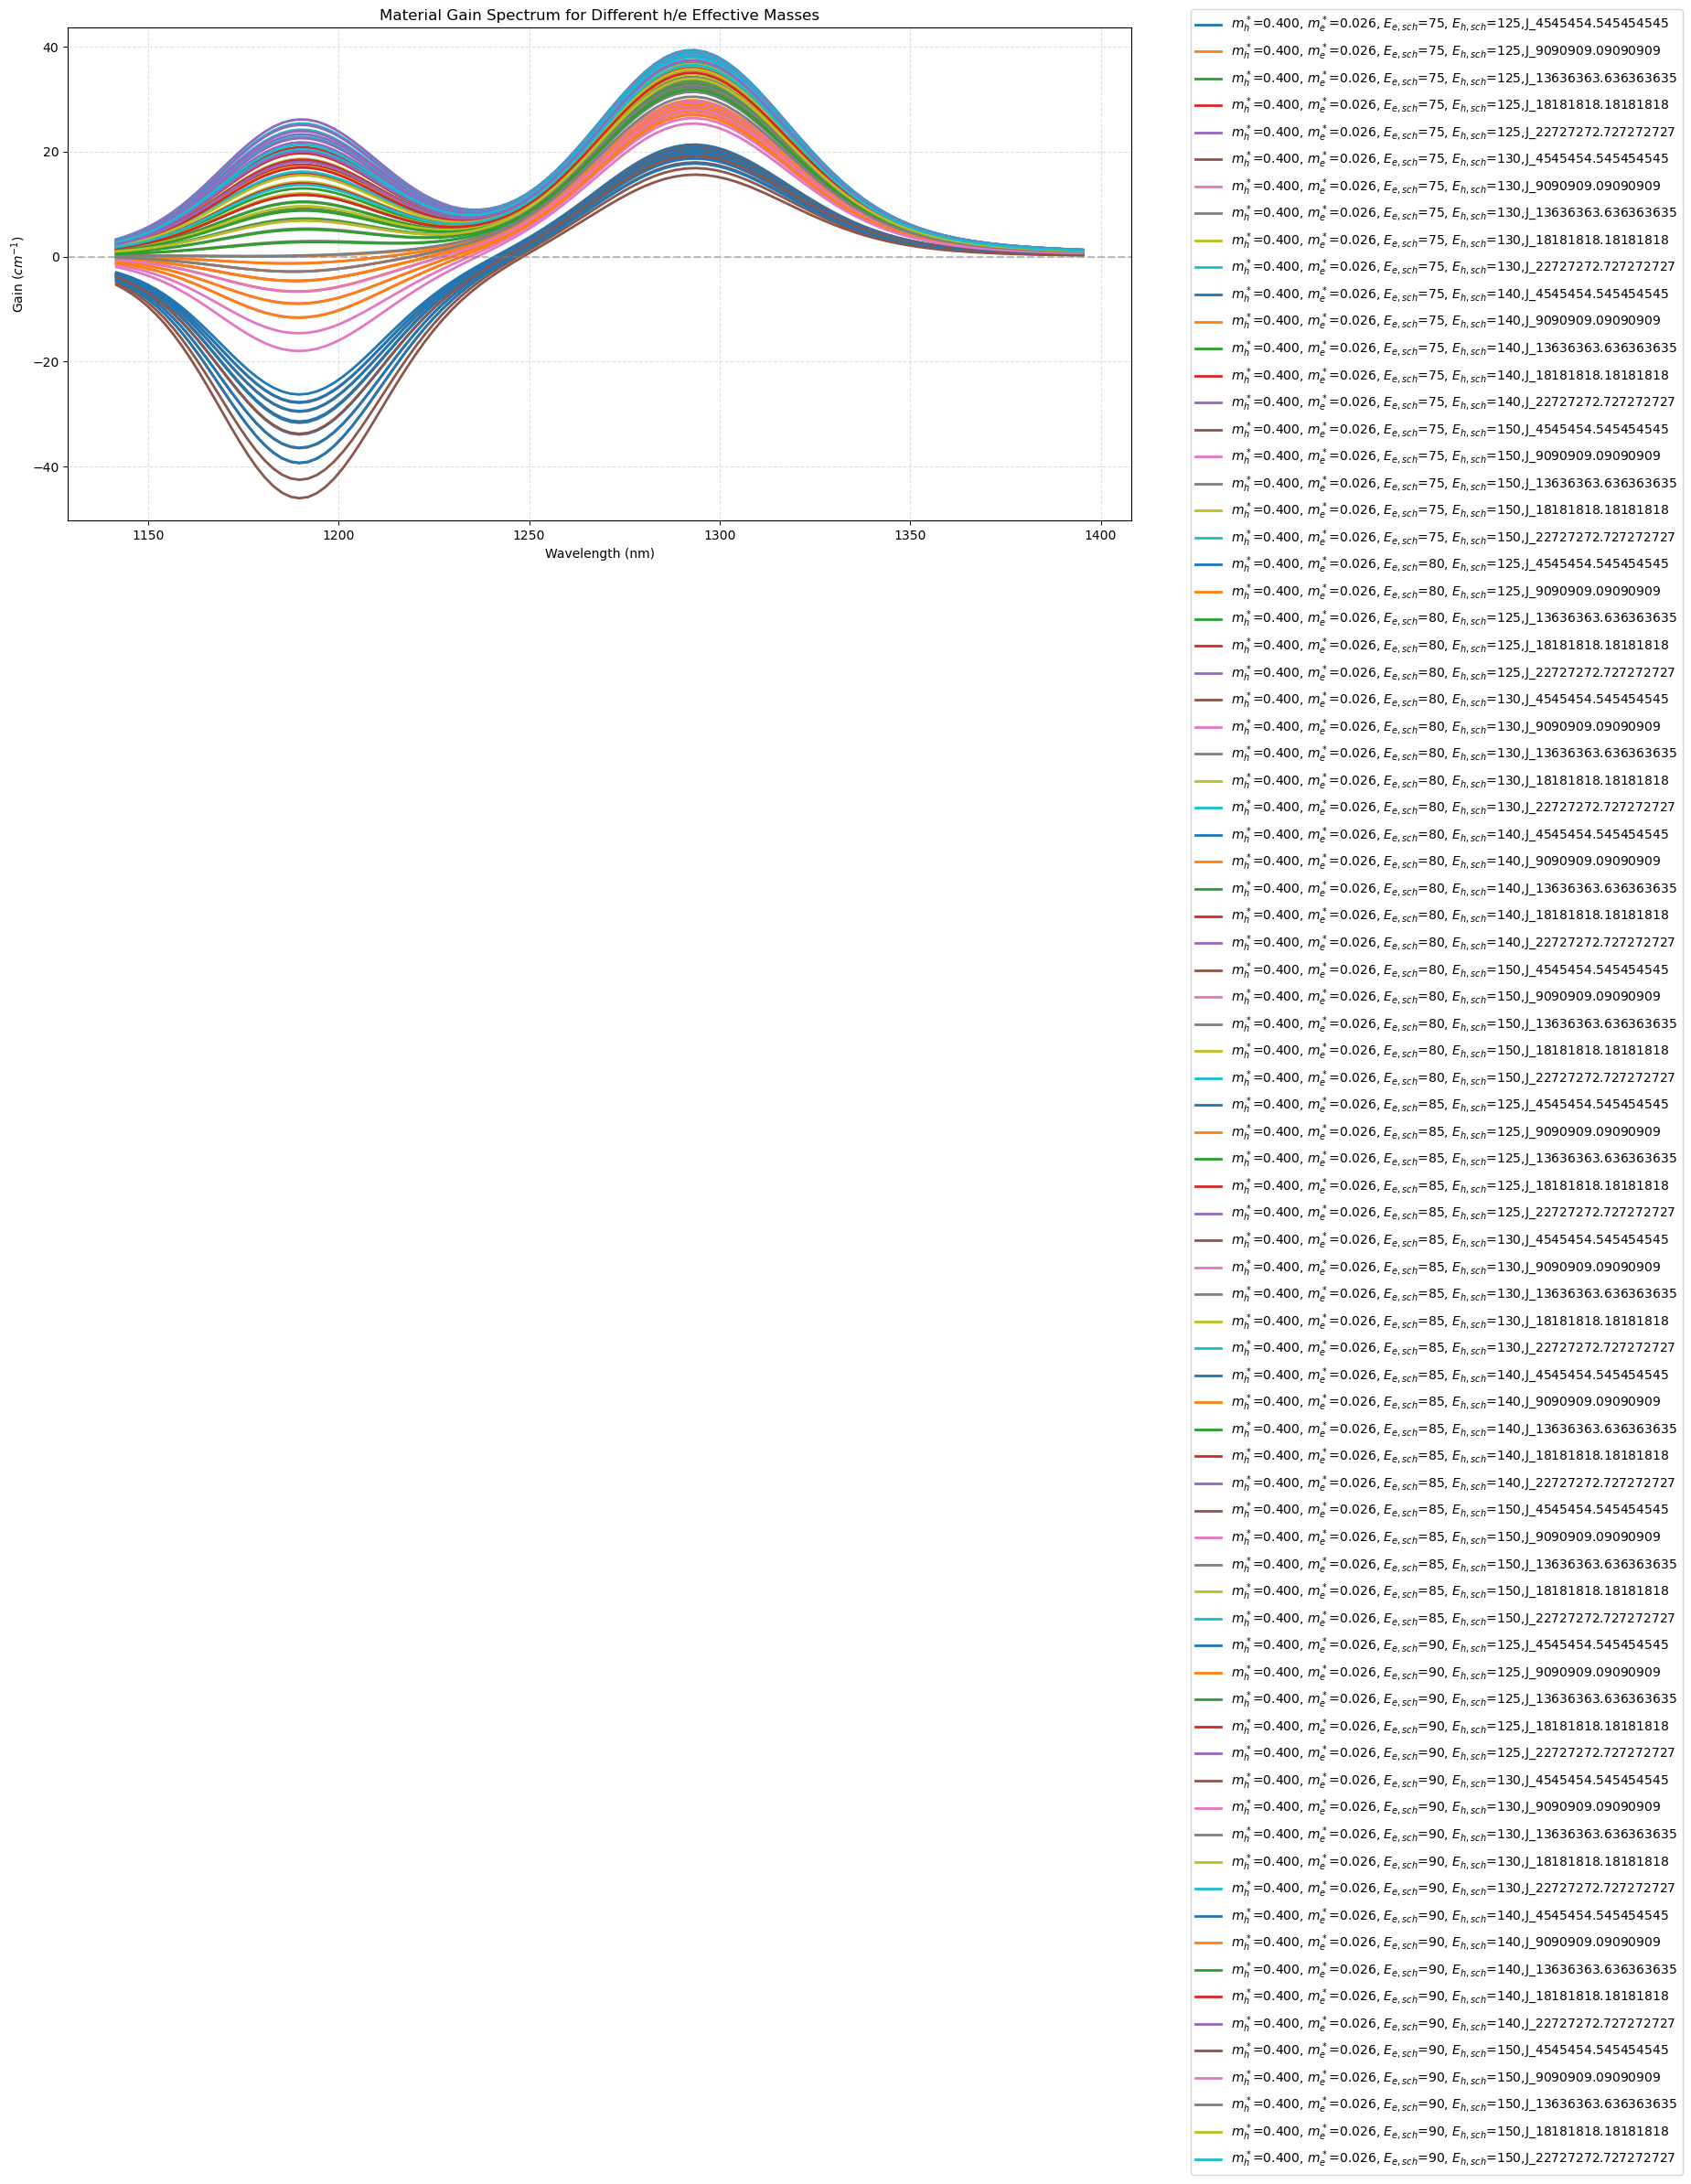

In [21]:
conversion_factor = params['omega_0'] / (3E8 * 3.3445)

plt.figure(figsize=(15, 7))

for index, (mh_factor, me_factor, E_sch, E_h,J_val) in enumerate(keys):
    #if mh_factor == 0.34:
    #    colour = 'red'
    #elif mh_factor == 0.375:
    #    colour = 'blue'

    plt.plot(
        wavelength,
        4019376.8605 * gain_array[index],
        lw=2,
        label=f'$m_h^*$={mh_factor:.3f}, $m_e^*$={me_factor:.3f}, '
              f'$E_{{e,sch}}$={E_sch}, $E_{{h,sch}}$={E_h},J_{J_val}',
        #color = colour
    )

plt.title('Material Gain Spectrum for Different h/e Effective Masses')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Gain ($cm^{-1}$)')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1.05))
plt.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

Experimental currents (mA): [2.0, 4.0, 6.0, 8.0, 10.0]

Rank m_h*   m_e*     E_sch   E_h     mean RMSE   
1    0.4    0.026    75      140     0.04184     
2    0.4    0.026    85      130     0.04215     
3    0.4    0.026    90      125     0.04227     
4    0.4    0.026    80      140     0.04277     
5    0.4    0.026    90      130     0.04321     
6    0.4    0.026    80      130     0.04499     
7    0.4    0.026    85      125     0.04511     
8    0.4    0.026    75      150     0.04903     
9    0.4    0.026    75      130     0.04956     
10   0.4    0.026    85      140     0.04962     
11   0.4    0.026    80      125     0.04974     
12   0.4    0.026    75      125     0.05484     
13   0.4    0.026    80      150     0.06195     
14   0.4    0.026    90      140     0.06286     
15   0.4    0.026    85      150     0.08056     
16   0.4    0.026    90      150     0.10462     


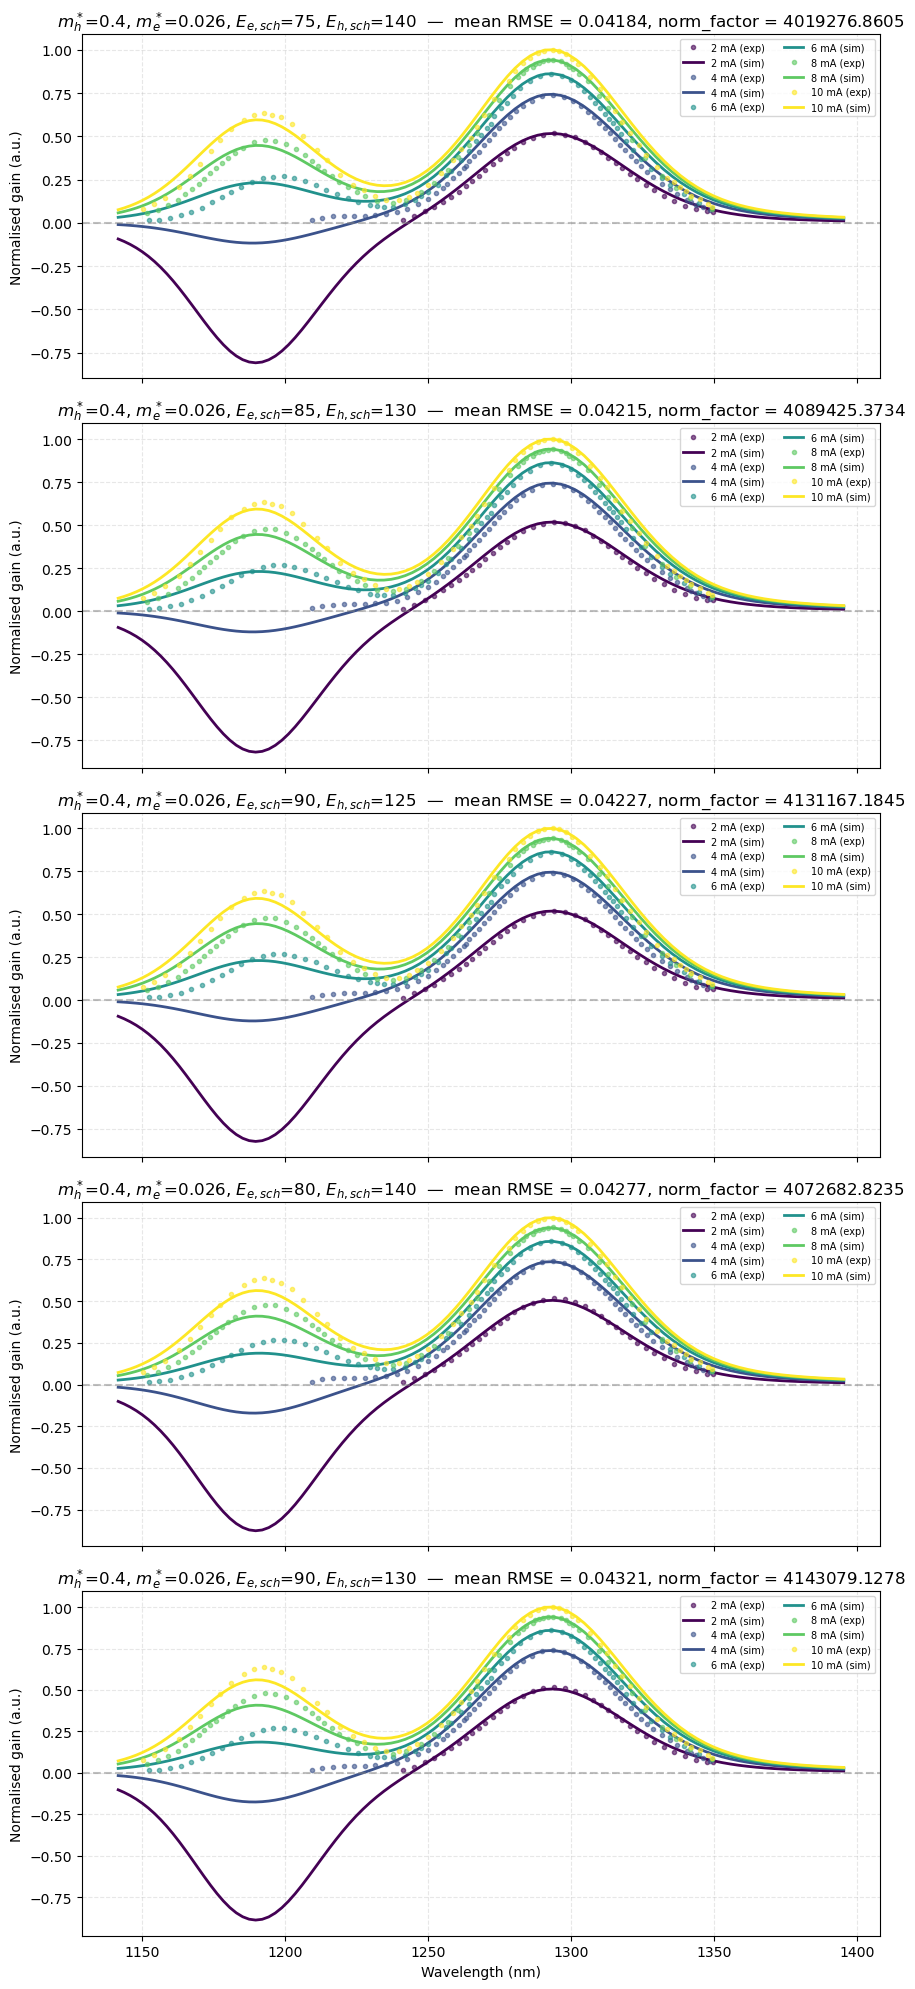

In [22]:
"""
Continuation of your existing notebook — run this AFTER your cell 2
(the one that builds `gain_array`, `keys`, and `wavelength`).

It assumes those three variables, plus J_array, m_h_w_arr, m_e_w_arr,
delta_E_sch_w_arr, delta_E_h_sch_w_arr from your earlier cells are
still in scope.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from collections import defaultdict

# =====================================================================
# 5. Load the digitised experimental gain spectra (WebPlotDigitizer CSV)
# =====================================================================
def load_experimental_data(csv_path):
    """
    Parses a WebPlotDigitizer 'wide' export with a 2-row header
    (top row = current label e.g. '2mA', second row = 'X'/'Y').

    Returns
    -------
    dict {current_mA (float): (wavelength_nm, gain_cm-1)}
        arrays sorted ascending by wavelength, NaN padding stripped.
    """
    raw = pd.read_csv(csv_path, header=[0, 1])
    # top-level labels repeat as 'Unnamed...' for the Y column of each pair
    labels = [c for c in raw.columns.get_level_values(0) if not str(c).startswith('Unnamed')]

    exp_data = {}
    for i, lab in enumerate(labels):
        xcol, ycol = raw.columns[2 * i], raw.columns[2 * i + 1]
        x = raw[xcol].dropna().values.astype(float)
        y = raw[ycol].dropna().values.astype(float)
        order = np.argsort(x)
        x, y = x[order], y[order]
        current_mA = float(lab.replace('mA', ''))
        exp_data[current_mA] = (x, y)
    return exp_data


experimental = load_experimental_data(r'C:\Users\josep\Documents\MRes mini-project 2\wpd_datasets.csv')
currents_sorted = sorted(experimental.keys())          # [2.0, 4.0, 6.0, 8.0, 10.0]
print("Experimental currents (mA):", currents_sorted)

# J_array (from your cell 1) is monotonically increasing; its i-th
# entry is taken to correspond to the i-th lowest-to-highest
# experimental current (confirmed: linspace(J, 5J, 5) -> exact
# multiples of the base 2 mA current, i.e. 2,4,6,8,10 mA).
J_sorted = np.sort(J_array)
assert len(J_sorted) == len(currents_sorted), \
    "J_array length must match the number of experimental currents"
J_to_current = dict(zip(J_sorted, currents_sorted))

# =====================================================================
# 6. Group the simulated spectra by (m_h_w, m_e_w, E_sch, E_h) and
#    compute a normalised RMSE against experiment for every current
# =====================================================================
# param_sets[(mh, me, E_sch, E_h)][current_mA] = gain_array row
param_sets = defaultdict(dict)
for idx, (mh, me, E_sch, E_h, J_val) in enumerate(keys):
    param_key = (mh, me, E_sch, E_h)
    current_mA = J_to_current[J_val]
    param_sets[param_key][current_mA] = gain_array[idx]

highest_current = max(currents_sorted)
# Experimental normalisation is fixed once — same reference for every
# parameter set, since there's no unknown pre-factor on the experimental side.
exp_norm_factor = np.max(experimental[highest_current][1])


def rmse_for_param_set(param_key, sim_dict):
    """
    Normalises this parameter set's simulated family to the peak of its
    OWN highest-current curve (this cancels the unknown pre-factor you
    mentioned you'll be tuning later), normalises experiment to the
    peak of the highest-current experimental curve, then computes RMSE
    per current on a common wavelength grid (the overlap of both ranges).
    """
    sim_norm_factor = np.max(sim_dict[highest_current])

    rmse_per_current = {}
    for cur in currents_sorted:
        if cur not in sim_dict:
            continue
        sim_gain_n = sim_dict[cur] / sim_norm_factor
        exp_wl, exp_gain = experimental[cur]
        exp_gain_n = exp_gain / exp_norm_factor

        lo = max(wavelength.min(), exp_wl.min())
        hi = min(wavelength.max(), exp_wl.max())
        grid = np.linspace(lo, hi, 200)

        sim_interp = interp1d(wavelength, sim_gain_n, bounds_error=False, fill_value=np.nan)
        exp_interp = interp1d(exp_wl, exp_gain_n, bounds_error=False, fill_value=np.nan)
        s_on, e_on = sim_interp(grid), exp_interp(grid)

        mask = ~np.isnan(s_on) & ~np.isnan(e_on)
        rmse_per_current[cur] = float(np.sqrt(np.mean((s_on[mask] - e_on[mask]) ** 2)))

    mean_rmse = float(np.mean(list(rmse_per_current.values())))
    return rmse_per_current, mean_rmse, sim_norm_factor


ranking = []
for param_key, sim_dict in param_sets.items():
    rmse_per_current, mean_rmse, sim_norm_factor = rmse_for_param_set(param_key, sim_dict)
    ranking.append({
        'key': param_key,
        'mean_rmse': mean_rmse,
        'rmse_per_current': rmse_per_current,
        'sim_norm_factor': sim_norm_factor,
    })

ranking.sort(key=lambda d: d['mean_rmse'])

print(f"\n{'Rank':<5}{'m_h*':<7}{'m_e*':<9}{'E_sch':<8}{'E_h':<8}{'mean RMSE':<12}")
for i, r in enumerate(ranking, 1):
    mh, me, E_sch, E_h = r['key']
    print(f"{i:<5}{mh:<7}{me:<9}{E_sch:<8}{E_h:<8}{r['mean_rmse']:<12.5f}")

# =====================================================================
# 7. Plot the 5 best-matching parameter sets, every current, normalised
# =====================================================================
top5 = ranking[:5]
colors = plt.cm.viridis(np.linspace(0, 1, len(currents_sorted)))

fig, axes = plt.subplots(len(top5), 1, figsize=(9, 4 * len(top5)), sharex=True)
if len(top5) == 1:
    axes = [axes]

for ax, r in zip(axes, top5):
    mh, me, E_sch, E_h = r['key']
    sim_dict = param_sets[r['key']]
    sim_norm_factor = r['sim_norm_factor']

    for cur, c in zip(currents_sorted, colors):
        exp_wl, exp_gain = experimental[cur]
        ax.plot(exp_wl, exp_gain / exp_norm_factor, 'o', ms=3, color=c, alpha=0.6,
                 label=f'{cur:g} mA (exp)')
        if cur in sim_dict:
            ax.plot(wavelength, sim_dict[cur] / sim_norm_factor, '-', lw=2, color=c,
                     label=f'{cur:g} mA (sim)')

    ratio = exp_norm_factor/sim_norm_factor

    ax.set_title(f"$m_h^*$={mh}, $m_e^*$={me}, $E_{{e,sch}}$={E_sch}, "
                 f"$E_{{h,sch}}$={E_h}  —  mean RMSE = {r['mean_rmse']:.5f}, norm_factor = {ratio:.4f}")
    ax.axhline(0, color='gray', ls='--', alpha=0.5)
    ax.grid(True, ls='--', alpha=0.3)
    ax.set_ylabel('Normalised gain (a.u.)')
    ax.legend(fontsize=7, ncol=2, loc='upper right')

axes[-1].set_xlabel('Wavelength (nm)')
plt.tight_layout()
plt.savefig('top5_param_sets_normalised.png', dpi=150)
plt.show()

In [24]:
# ============================================================
# Find and plot the 5 curves with zero-crossings closest to target
# ============================================================

TARGET_WAVELENGTH_NM = 1241.0
N_BEST = 10

wavelength = np.array(wavelength)  # ensure numpy array

def find_long_wavelength_intercept(wl, gain):
    """
    Find the zero-crossing where gain goes from negative to positive
    in the main gain-onset region (focused around 1200–1300 nm).
    """
    sort_idx   = np.argsort(wl)
    wl_sorted   = wl[sort_idx]
    gain_sorted = gain[sort_idx]

    mask   = (wl_sorted >= 1200) & (wl_sorted <= 1300)
    wl_r   = wl_sorted[mask]
    gain_r = gain_sorted[mask]

    for i in range(len(gain_r) - 1):
        if gain_r[i] < 0 and gain_r[i + 1] >= 0:
            frac = -gain_r[i] / (gain_r[i + 1] - gain_r[i])
            return wl_r[i] + frac * (wl_r[i + 1] - wl_r[i])

    return None

# ── Compute intercepts for all curves ────────────────────────
intercept_data = []

for index, (mh_factor, me_factor, E_sch, E_h) in enumerate(keys):
    gain_drummer = conversion_factor * gain_array[index]
    intercept = find_long_wavelength_intercept(wavelength, gain_drummer)

    if intercept is not None:
        distance = abs(intercept - TARGET_WAVELENGTH_NM)
        intercept_data.append((distance, intercept, index, (mh_factor, me_factor, E_sch, E_h)))

intercept_data.sort(key=lambda x: x[0])

# ── Print results ─────────────────────────────────────────────
if not intercept_data:
    print("No curves with a valid zero-crossing found in the 1200–1300 nm window.")
else:
    best = intercept_data[:N_BEST]

    print(f"Top {len(best)} curves closest to {TARGET_WAVELENGTH_NM} nm transparency point:\n")
    for rank, (dist, intercept, index, (mh, me, E_sch, E_h)) in enumerate(best):
        print(
            f"  #{rank+1}: intercept = {intercept:.2f} nm  (Δ = {dist:.2f} nm)\n"
            f"         m_h* = {mh:.3f},  m_e* = {me:.4f},  "
            f"E_e,sch = {E_sch} meV,  E_h,sch = {E_h} meV"
        )

    # ── Plot ──────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 5))

    for rank, (dist, intercept, index, (mh, me, E_sch, E_h)) in enumerate(best):
        gain_drum = conversion_factor * gain_array[index]
        line, = ax.plot(
            wavelength, gain_drum, lw=2,
            label=(f'#{rank+1}: {intercept:.1f} nm  |  '
                   f'$m_h^*$={mh:.3f}, $m_e^*$={me:.4f}, '
                   f'$E_e$={E_sch}, $E_h$={E_h}')
        )
        ax.axvline(intercept, color=line.get_color(), lw=0.8, linestyle=':', alpha=0.6)

    ax.axvline(TARGET_WAVELENGTH_NM, color='black', linestyle='--', lw=1.5,
               label=f'Target: {TARGET_WAVELENGTH_NM} nm', alpha=0.8)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)

    ax.set_title(f'Top {N_BEST} curves closest to {TARGET_WAVELENGTH_NM} nm transparency point')
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('Gain ($cm^{{-1}}$)')
    ax.legend(loc='best', fontsize=7)
    ax.grid(True, ls='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

ValueError: too many values to unpack (expected 4)

2.869769446792076e-12 7.290147443730576e-12 8.69583775338522e-11 1.5507328851608195e-11
    0.0%  t = 0.000 ns
   10.0%  t = 2.000 ns
   20.0%  t = 4.000 ns
   30.0%  t = 6.000 ns
   40.0%  t = 8.000 ns
   50.0%  t = 10.000 ns
   60.0%  t = 12.000 ns
   70.0%  t = 14.000 ns
   80.0%  t = 16.000 ns
   90.0%  t = 18.000 ns
  100.0%  t = 20.000 ns
  Done.
  ρ_e(GS)=0.9597  ρ_e(ES1)=0.6096
  ρ_h(GS)=0.2482  ρ_h(ES1)=0.1719
  Gain factor GS:  0.2078
  Gain factor ES1: -0.2185
2.869769446792076e-12 7.290147443730576e-12 8.69583775338522e-11 1.5507328851608195e-11
    0.0%  t = 0.000 ns
   10.0%  t = 2.000 ns
   20.0%  t = 4.000 ns
   30.0%  t = 6.000 ns
   40.0%  t = 8.000 ns
   50.0%  t = 10.000 ns
   60.0%  t = 12.000 ns
  Converged at step 417223  (t = 12.517 ns)
  Done.
  ρ_e(GS)=0.9804  ρ_e(ES1)=0.7695
  ρ_h(GS)=0.3047  ρ_h(ES1)=0.2161
  Gain factor GS:  0.2850
  Gain factor ES1: -0.0144
2.869769446792076e-12 7.290147443730576e-12 8.69583775338522e-11 1.5507328851608195e-11
    0.0%  t 

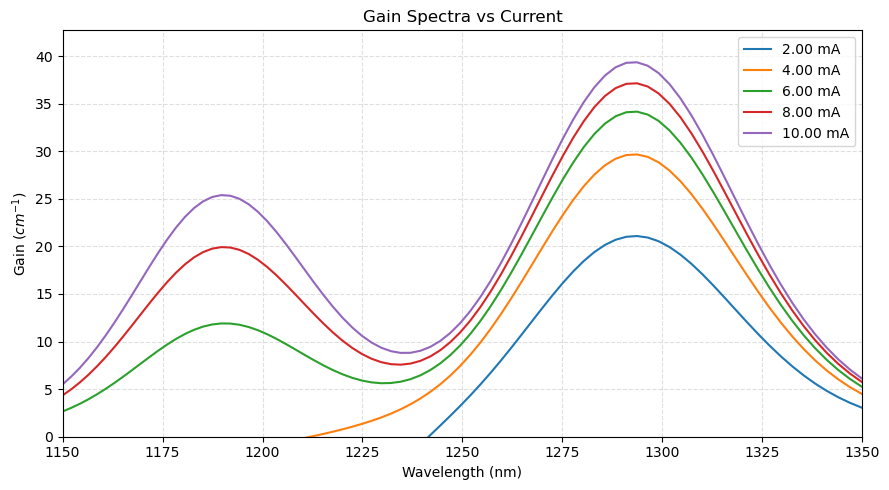

In [30]:
# ============================================================
# Cell 5 — Define initial values and run
# ============================================================

initial_values = {
    'n_e_sch' : 0.0,
    'n_e_w'   : 0.0,
    'n_e_im'  : np.zeros((n_m, N)),
    'n_h_sch' : 0.0,
    'n_hq_qd' : 1e6,
}

t_end = 20e-9
tstep = 30e-15
J     = 2E-3 / (2.2E-6 * 200E-6)

N_arr     = 5
len_omega = 100
J_array   = np.linspace(J, 5*J, N_arr)
gain_array = np.zeros((N_arr, len_omega))
N_array    = np.zeros(N_arr)

for index, current in enumerate(J_array):
    t_final, final_state, step = run_qd_simulation(
        t_end, initial_values, tstep,
        J=current, threshold=0.05,
        m_h_w=0.4, m_e_w=0.026,
        delta_E_sch_w=75, delta_E_h_sch_w=130,
    )
    result_output = plot_gain_and_carriers(
        final_state,
        len_omega=len_omega,
        m_h_w=0.4,
    )
    gain_array[index] = result_output['gain_cm_minus_1']
    N_array[index]    = result_output['total_electrons']

wavelength        = result_output['wavelength_nm']
conversion_factor = params['omega_0'] / (3E8 * 3.3445)
np.save('gain_array.npy',gain_array)
np.save('N_array.npy', N_array)


plt.figure(figsize=(9, 5))
for i, current in enumerate(J_array):
    plt.plot(
        wavelength,
        4019376.8605 * gain_array[i],
        label=f'{current * 2.2E-6 * 200E-6 * 1E3:.2f} mA',
    )

plt.xlim(1150, 1350)
plt.ylim(bottom=0)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Gain ($cm^{-1}$)')
plt.title('Gain Spectra vs Current')
plt.legend()
plt.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [31]:
import os
import pandas as pd

# 1. Define paths (anchored to your project directory)
base_dir = r"C:\Users\josep\Documents\MRes mini-project 2"
output_dir = os.path.join(base_dir, "Graphs")

# Automatically create the 'Graphs' folder if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# 2. Structure the data into a dictionary
# Start with the wavelength column
export_dict = {
    'Wavelength_nm': wavelength
}

# Add each simulated curve as its own column, using the mA value as the header
for i, current in enumerate(J_array):
    current_mA = current * 2.2E-6 * 200E-6 * 1E3
    column_header = f'Gain_Sim_{current_mA:.2f}mA'
    export_dict[column_header] = gain_array[i]

# 3. Convert to DataFrame and save
df_save = pd.DataFrame(export_dict)
output_path = os.path.join(output_dir, "simulated_gain_spectra.csv")
df_save.to_csv(output_path, index=False)

print(f"Successfully saved simulated data to:\n{output_path}")

Successfully saved simulated data to:
C:\Users\josep\Documents\MRes mini-project 2\Graphs\simulated_gain_spectra.csv


In [ ]:
import pandas as pd

# Load the data back in
df_loaded = pd.read_csv(r"C:\Users\josep\Documents\MRes mini-project 2\Graphs\simulated_gain_spectra.csv")

# Extract arrays if needed
wavelengths = df_loaded['Wavelength_nm'].to_numpy()
# Get a specific gain column by its string name
gain_4mA = df_loaded['Gain_Sim_4.00mA'].to_numpy()


2.00 mA:
  λ = 1293.7 nm,  gain = 21.0 cm⁻¹

4.00 mA:
  λ = 1293.7 nm,  gain = 29.5 cm⁻¹

6.00 mA:
  λ = 1293.7 nm,  gain = 34.0 cm⁻¹
  λ = 1189.7 nm,  gain = 11.9 cm⁻¹

8.00 mA:
  λ = 1293.7 nm,  gain = 37.0 cm⁻¹
  λ = 1189.7 nm,  gain = 19.8 cm⁻¹

10.00 mA:
  λ = 1293.7 nm,  gain = 39.2 cm⁻¹
  λ = 1189.7 nm,  gain = 25.3 cm⁻¹


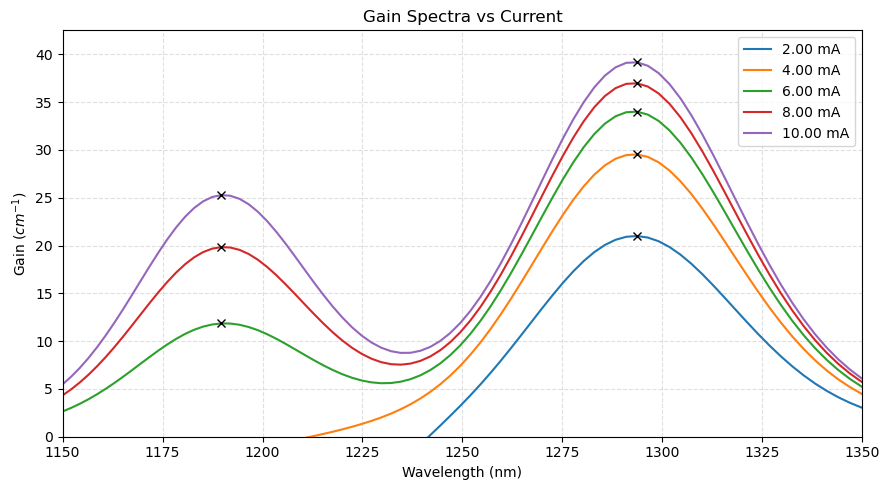

In [32]:
from scipy.signal import find_peaks

wavelength        = result_output['wavelength_nm']
conversion_factor = params['omega_0'] / (3E8 * 3.3445)

plt.figure(figsize=(9, 5))

for i, current in enumerate(J_array):
    gain = conversion_factor * 39.2/56.9 * 4 * gain_array[i]
    I_mA = current * 2.2E-6 * 200E-6 * 1E3

    # Find peaks — tune prominence/height as needed
    peaks, props = find_peaks(gain, height=0, prominence=1)

    plt.plot(wavelength, gain, label=f'{I_mA:.2f} mA')
    plt.plot(wavelength[peaks], gain[peaks], 'x', color='black')

    print(f"\n{I_mA:.2f} mA:")
    for p in peaks:
        print(f"  λ = {wavelength[p]:.1f} nm,  gain = {gain[p]:.1f} cm⁻¹")

plt.xlim(1150, 1350)
plt.ylim(bottom=0)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Gain ($cm^{-1}$)')
plt.title('Gain Spectra vs Current')
plt.legend()
plt.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.show()
plt.show()

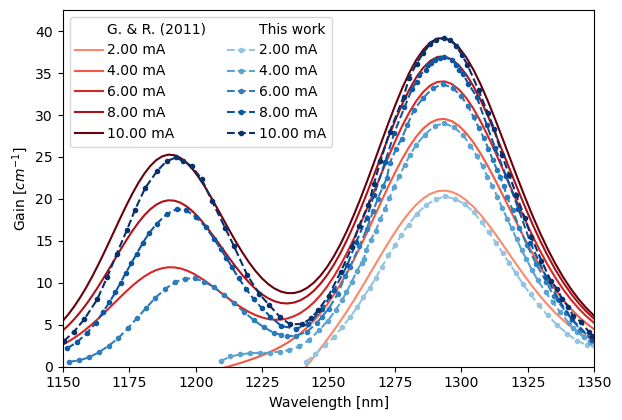

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch  # Imported to create invisible headers

# ── Load and parse the CSV ────────────────────────────────────
raw = pd.read_csv(r"C:\Users\josep\Documents\MRes mini-project 2\wpd_datasets.csv", header=None)

dataset_names = raw.iloc[0, ::2].tolist()
n_datasets    = len(dataset_names)

datasets = []
for i in range(n_datasets):
    x_col = i * 2
    y_col = i * 2 + 1
    df = raw.iloc[2:, [x_col, y_col]].copy()
    df.columns = ['x', 'y']
    df = df.dropna().astype(float).sort_values('x')
    datasets.append(df)

current_labels = [
    '2.00 mA',   
    '4.00 mA',   
    '6.00 mA',   
    '8.00 mA',   
    '10.00 mA',  
]

# ── Plot alongside simulated gain curves ─────────────────────
conversion_factor = params['omega_0'] / (3E8 * 3.3445)

fig, ax = plt.subplots(figsize=(6.32, 4.3))

sim_colors = plt.cm.Reds(np.linspace(0.4, 1.0, len(J_array)))
exp_colors = plt.cm.Blues(np.linspace(0.4, 1.0, len(datasets)))

# Lists to manually collect handles and labels
sim_handles, sim_labels = [], []
exp_handles, exp_labels = [], []

# 1. Generate Simulated curves (G. & R.)
for i, current in enumerate(J_array):
    current_mA = current * 2.2E-6 * 200E-6 * 1E3
    line, = ax.plot(
        wavelength,
        conversion_factor * 2.756 * gain_array[i],
        color=sim_colors[i],
    )
    sim_handles.append(line)
    sim_labels.append(f'{current_mA:.2f} mA')

# 2. Generate Experimental curves (This work)
for i, (df, label) in enumerate(zip(datasets, current_labels)):
    line, = ax.plot(
        df['x'], df['y'],
        ls='--', marker='o', markersize=3,
        color=exp_colors[i],
    )
    exp_handles.append(line)
    exp_labels.append(label)

# 3. Construct the Structured Legend
# Create invisible handles for the column headers
header_sim_handle = Patch(color='none')
header_exp_handle = Patch(color='none')

header_sim_label = 'G. & R. (2011)'
header_exp_label = 'This work'

# Since matplotlib fills columns vertically, list ALL of column 1, then ALL of column 2
final_handles = [header_sim_handle] + sim_handles + [header_exp_handle] + exp_handles
final_labels = [header_sim_label] + sim_labels + [header_exp_label] + exp_labels

# Render the legend with 2 columns
ax.legend(
    final_handles, 
    final_labels, 
    ncol=2, 
    handletextpad=0.3,    # Shriniks the spacer next to the invisible headers
    columnspacing=1.5     # Adds a clean gap between the two columns
)

ax.set_xlim(1150, 1350)
ax.set_ylim(bottom=0)
ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Gain [$cm^{-1}$]')
plt.tight_layout()
plt.show()